# Ejercicios 2 y 3 — Estadística descriptiva y correlaciones


- **Ejercicio 2:** Estadística descriptiva y preguntas de exploración (5 pts)
- **Ejercicio 3:** Relaciones entre variables numéricas (5 pts)


In [18]:
#Imports y sesión de Spark
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

spark = (SparkSession.builder
         .master("local[*]")
         .appName("Lab7-Ej2Ej3")
         .config("spark.driver.memory", "4g")
         .getOrCreate())

print("Spark", spark.version)

Spark 3.5.1


26/09/24 22:52:22 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/09/24 22:52:22 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [19]:
# ── Lectura de los conjuntos preparados
PARQUET_DIR = "../working_dir/parquet"

df = spark.read.parquet(f"{PARQUET_DIR}/eneic_2025_preparado").persist()

print(f"Registros en la población analítica de 2025: {df.count():,}")
df.printSchema()

Registros en la población analítica de 2025: 53,025
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- antiguedad: double (nullable = true)



In [20]:
# ── Etiquetas legibles para códigos categóricos
ETIQUETAS_CAT_OCUP = {
    "1": "Emp. gobierno",
    "2": "Emp. privada",
    "3": "Jornalero/peón",
    "4": "Serv. doméstico",
}

ETIQUETAS_DOMINIO = {
    "1": "Urbano metropolitano",
    "2": "Resto urbano",
    "3": "Rural",
}

ETIQUETAS_EDUC = {
    "0": "Ninguno",
    "1": "Preprimaria",
    "2": "Primaria",
    "3": "Básico",
    "4": "Diversificado",
    "5": "Superior",
    "6": "Maestría",
    "7": "Doctorado",
}

def aplicar_etiquetas(pdf, col, etiquetas):
    #Reemplaza códigos por etiquetas en un DataFrame de pandas.
    pdf = pdf.copy()
    pdf[col] = pdf[col].map(lambda x: etiquetas.get(str(x), f"DESCONOCIDO ({x})"))
    return pdf

---
# Ejercicio 2 — Estadística descriptiva y preguntas de exploración (5 pts)

## 2.1 Estadísticos descriptivos de las variables numéricas

Para la población analítica de 2025 se calculan: N, media, mediana, desviación estándar, mínimo, máximo, P25, P75 y P95 de salario_mensual, edad, antiguedad y horas_semanales.

In [21]:
# ── Estadísticos descriptivos con Spark ─────────────────────────────────
VARS_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def resumen_descriptivo(df, columnas):
    """Calcula estadísticos descriptivos completos en Spark."""
    filas = []
    for c in columnas:
        base = (df.select(
                    F.count(F.col(c)).alias("n"),
                    F.mean(c).alias("media"),
                    F.stddev(c).alias("desv_std"),
                    F.min(c).alias("minimo"),
                    F.max(c).alias("maximo"))
                .collect()[0])
        p25, mediana, p75, p95 = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.95], 0.0)
        filas.append({
            "variable": c, "n": base["n"], "media": base["media"],
            "mediana": mediana, "desv_std": base["desv_std"],
            "minimo": base["minimo"], "maximo": base["maximo"],
            "p25": p25, "p75": p75, "p95": p95,
        })
    return pd.DataFrame(filas).set_index("variable").round(2)

tabla_descriptiva = resumen_descriptivo(df, VARS_NUM)
tabla_descriptiva

,n,media,mediana,desv_std,minimo,maximo,p25,p75,p95
variable,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
edad,53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
antiguedad,53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,22.0
horas_semanales,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


### Interpretación

- **Salario mensual:** La media es considerablemente mayor que la mediana, lo que indica una distribución con sesgo positivo con asimetría a la derecha. Existen salarios muy altos que elevan el promedio pero no afectan la mediana. El P95 muestra que el 5 % de los salarios más altos son considerablemente superiores al resto.
- **Edad:** La distribución se concentra en adultos en edad laboral, con mediana y media relativamente cercanas.
- **Antigüedad:** La mediana baja indica que gran parte de los asalariados tiene poca antigüedad en su empleo actual. La media es más alta por trabajadores con muchos años de servicio.
- **Horas semanales:** La mediana cercana a las 40-48 horas refleja jornadas típicas, con variabilidad hacia ambos extremos.

## 2.2 Distribución por categorías ocupacionales, niveles educativos y dominios

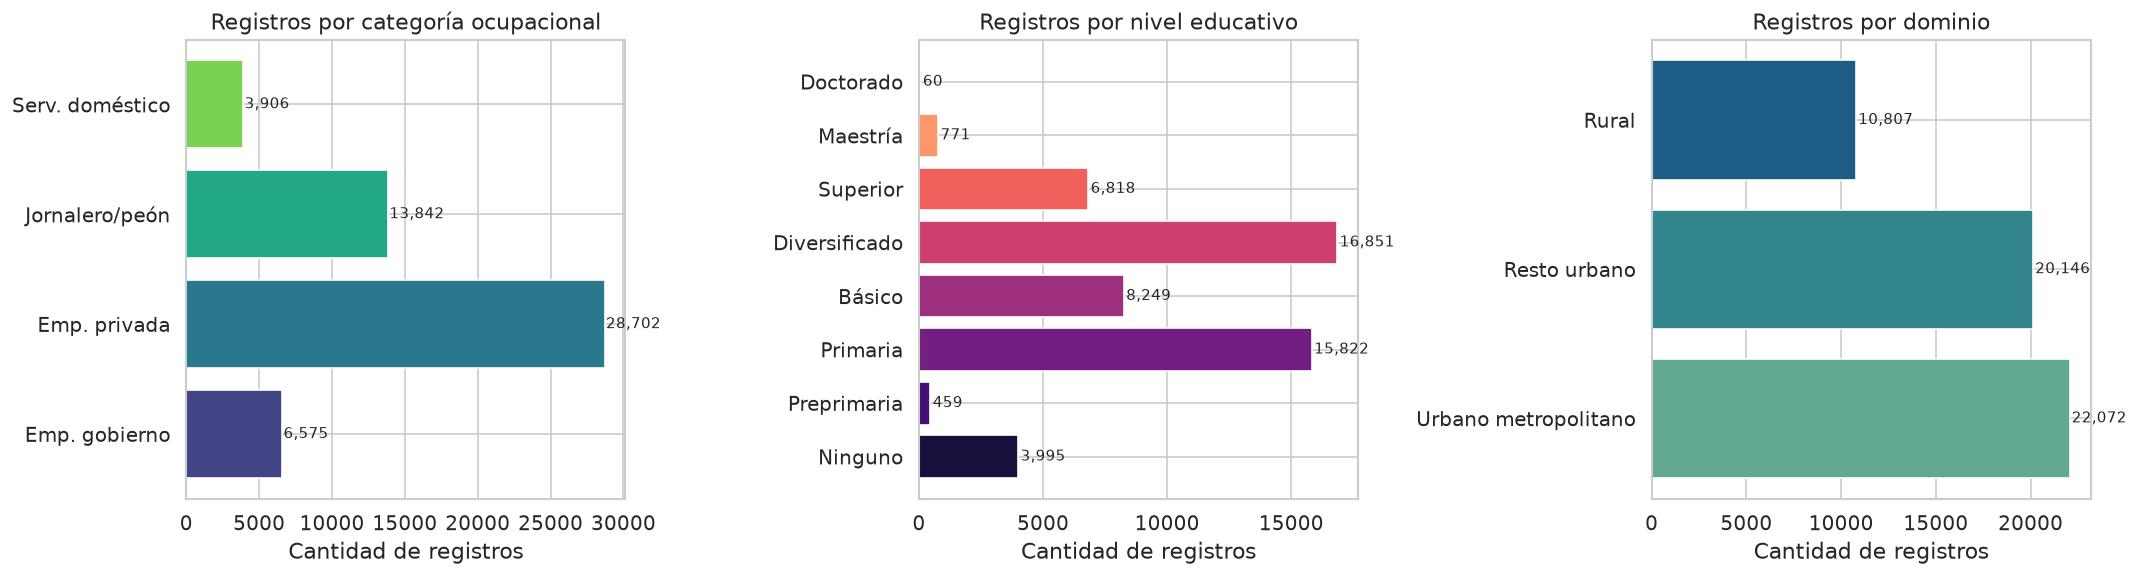

In [22]:
# ── Conteos por categoría (agregados en Spark)
conteo_cat = aplicar_etiquetas(
    df.groupBy("categoria_ocupacional").count().orderBy("categoria_ocupacional").toPandas(),
    "categoria_ocupacional", ETIQUETAS_CAT_OCUP)

conteo_educ = aplicar_etiquetas(
    df.groupBy("nivel_educativo").count().orderBy("nivel_educativo").toPandas(),
    "nivel_educativo", ETIQUETAS_EDUC)

conteo_dom = aplicar_etiquetas(
    df.groupBy("dominio").count().orderBy("dominio").toPandas(),
    "dominio", ETIQUETAS_DOMINIO)

# ── Gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Categoría ocupacional
ax = axes[0]
bars = ax.barh(conteo_cat["categoria_ocupacional"], conteo_cat["count"],
               color=sns.color_palette("viridis", len(conteo_cat)))
ax.set_xlabel("Cantidad de registros")
ax.set_title("Registros por categoría ocupacional")
for bar, val in zip(bars, conteo_cat["count"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)

# Nivel educativo
ax = axes[1]
bars = ax.barh(conteo_educ["nivel_educativo"], conteo_educ["count"],
               color=sns.color_palette("magma", len(conteo_educ)))
ax.set_xlabel("Cantidad de registros")
ax.set_title("Registros por nivel educativo")
for bar, val in zip(bars, conteo_educ["count"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)

# Dominio
ax = axes[2]
bars = ax.barh(conteo_dom["dominio"], conteo_dom["count"],
               color=sns.color_palette("crest", len(conteo_dom)))
ax.set_xlabel("Cantidad de registros")
ax.set_title("Registros por dominio")
for bar, val in zip(bars, conteo_dom["count"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretación

- **Categoría ocupacional:** Los empleados de empresa privada representan la mayor proporción de asalariados, seguidos por jornaleros/peones y empleados de gobierno. El servicio doméstico es la categoría más pequeña.
- **Nivel educativo:** Los niveles primaria y diversificado concentran la mayor parte de los registros, lo que refleja el perfil educativo de la fuerza laboral asalariada en Guatemala.
- **Dominio:** Los tres dominios están relativamente balanceados, con ligera predominancia del resto urbano.

## 2.3 ¿El salario presenta una distribución simétrica o asimétrica?

El histograma se construye mediante binning en Spark: se calculan los conteos por bin directamente, sin transferir la columna completa a pandas. El boxplot se construye con los cuantiles ya calculados en 2.1.

In [23]:
# ── Histograma con binning en Spark
df_log = df.withColumn("log10_salario", F.log10("salario_mensual"))

min_log, max_log = df_log.select(
    F.min("log10_salario"), F.max("log10_salario")).first()

n_bins = 40
ancho = (max_log - min_log) / n_bins

df_bins = df_log.withColumn(
    "bin",
    F.least(
        F.floor((F.col("log10_salario") - F.lit(min_log)) / F.lit(ancho)),
        F.lit(n_bins - 1))
)

hist_log = (df_bins.groupBy("bin").count()
            .orderBy("bin").toPandas())
hist_log["centro_log10"] = min_log + (hist_log["bin"] + 0.5) * ancho

# Lo mismo en escala lineal
min_sal = tabla_descriptiva.loc["salario_mensual", "minimo"]
max_sal = tabla_descriptiva.loc["salario_mensual", "maximo"]
ancho_lin = (max_sal - min_sal) / n_bins

df_bins_lin = df.withColumn(
    "bin",
    F.least(
        F.floor((F.col("salario_mensual") - F.lit(min_sal)) / F.lit(ancho_lin)),
        F.lit(n_bins - 1))
)
hist_lin = (df_bins_lin.groupBy("bin").count()
            .orderBy("bin").toPandas())
hist_lin["centro"] = min_sal + (hist_lin["bin"] + 0.5) * ancho_lin

# Valores de referencia
media_sal = tabla_descriptiva.loc["salario_mensual", "media"]
mediana_sal = tabla_descriptiva.loc["salario_mensual", "mediana"]

print(f"Media del salario (todos los datos):   Q {media_sal:,.2f}")
print(f"Mediana del salario (todos los datos): Q {mediana_sal:,.2f}")
print(f"Diferencia media − mediana:            Q {media_sal - mediana_sal:,.2f}")

Media del salario (todos los datos):   Q 3,421.68
Mediana del salario (todos los datos): Q 3,000.00
Diferencia media − mediana:            Q 421.68


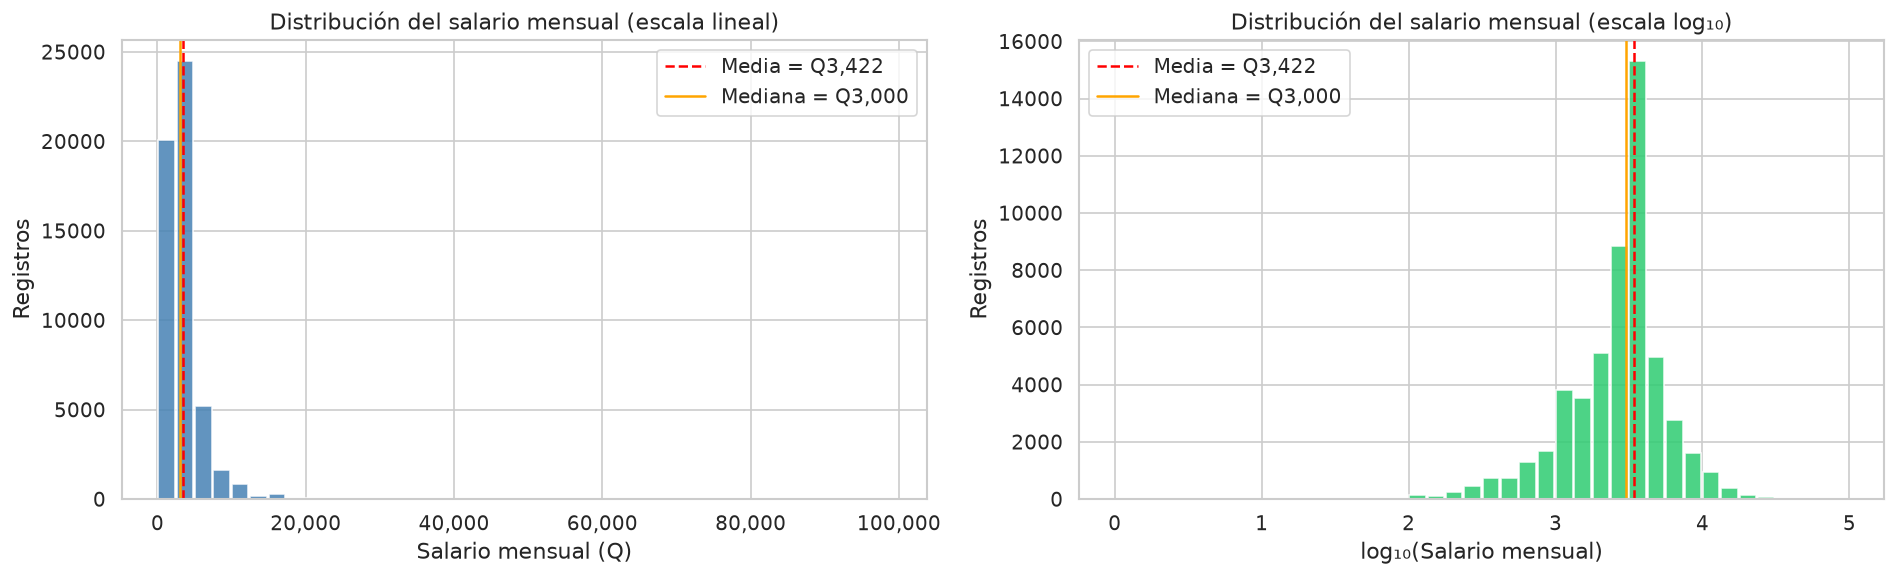

In [24]:
# ── Gráficas: histograma lineal + histograma log
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Escala lineal
ax = axes[0]
ax.bar(hist_lin["centro"], hist_lin["count"],
       width=ancho_lin * 0.9, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(media_sal, color="red", ls="--", lw=1.5, label=f"Media = Q{media_sal:,.0f}")
ax.axvline(mediana_sal, color="orange", ls="-", lw=1.5, label=f"Mediana = Q{mediana_sal:,.0f}")
ax.set_xlabel("Salario mensual (Q)")
ax.set_ylabel("Registros")
ax.set_title("Distribución del salario mensual (escala lineal)")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Escala logarítmica
ax = axes[1]
ax.bar(hist_log["centro_log10"], hist_log["count"],
       width=ancho * 0.9, color="#2ecc71", edgecolor="white", alpha=0.85)
ax.axvline(np.log10(media_sal), color="red", ls="--", lw=1.5,
           label=f"Media = Q{media_sal:,.0f}")
ax.axvline(np.log10(mediana_sal), color="orange", ls="-", lw=1.5,
           label=f"Mediana = Q{mediana_sal:,.0f}")
ax.set_xlabel("log₁₀(Salario mensual)")
ax.set_ylabel("Registros")
ax.set_title("Distribución del salario mensual (escala log₁₀)")
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_3237/2441429241.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.bxp([stats_salario], vert=False, showfliers=False,


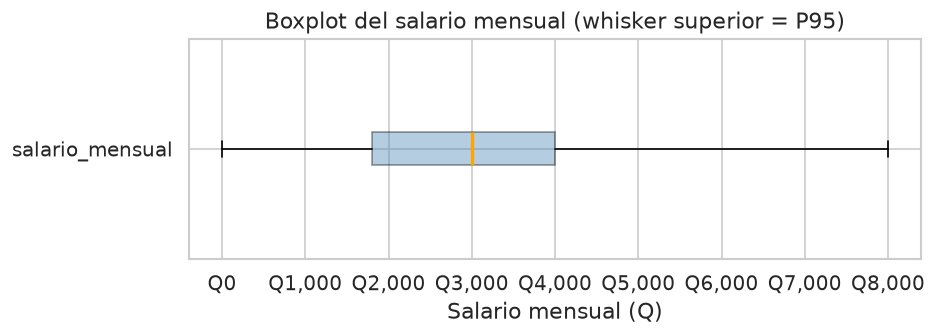

In [25]:
# ── Boxplot construido con los cuantiles ya calculados
stats_salario = {
    "label": "salario_mensual",
    "med":    tabla_descriptiva.loc["salario_mensual", "mediana"],
    "q1":     tabla_descriptiva.loc["salario_mensual", "p25"],
    "q3":     tabla_descriptiva.loc["salario_mensual", "p75"],
    "whislo": tabla_descriptiva.loc["salario_mensual", "minimo"],
    "whishi": tabla_descriptiva.loc["salario_mensual", "p95"],
    "fliers": [],
}

fig, ax = plt.subplots(figsize=(8, 3))
ax.bxp([stats_salario], vert=False, showfliers=False,
        boxprops=dict(facecolor="steelblue", alpha=0.4),
        medianprops=dict(color="orange", lw=2),
        patch_artist=True)
ax.set_xlabel("Salario mensual (Q)")
ax.set_title("Boxplot del salario mensual (whisker superior = P95)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Q{x:,.0f}"))
plt.tight_layout()
plt.show()

### Interpretación

El salario mensual presenta una distribución fuertemente asimétrica positiva (sesgada a la derecha):

- La mayoría de los asalariados se concentra en los salarios bajos, con una cola larga hacia valores altos.
- La media es mayor que la mediana, lo que confirma el sesgo positivo. Unos pocos salarios muy altos elevan el promedio sin afectar la mediana.
- En escala logarítmica, la distribución se ve más simétrica (aproximadamente log-normal), lo que es común en distribuciones salariales.
- Para el modelado se conservará el salario en su escala original (quetzales), como indica el enunciado.

## 2.4 Salario mediano por nivel educativo y por categoría ocupacional

In [26]:
# ── Salario mediano por grupo (agregado en Spark)
def mediana_por_grupo(df, col_grupo, col_valor="salario_mensual"):
    return (df.groupBy(col_grupo)
              .agg(F.count(col_valor).alias("n"),
                   F.percentile_approx(col_valor, 0.5).alias("mediana_salario"),
                   F.mean(col_valor).alias("media_salario"))
              .orderBy(col_grupo)
              .toPandas())

sal_educ = aplicar_etiquetas(
    mediana_por_grupo(df, "nivel_educativo"),
    "nivel_educativo", ETIQUETAS_EDUC)

sal_cat = aplicar_etiquetas(
    mediana_por_grupo(df, "categoria_ocupacional"),
    "categoria_ocupacional", ETIQUETAS_CAT_OCUP)

print("Salario mediano por nivel educativo:")
display(sal_educ)
print("\nSalario mediano por categoría ocupacional:")
display(sal_cat)

Salario mediano por nivel educativo:


,nivel_educativo,n,mediana_salario,media_salario
0,Ninguno,3995,1500.0,1767.091114
1,Preprimaria,459,2160.0,2241.897603
2,Primaria,15822,2200.0,2307.956390
3,Básico,8249,2800.0,2730.200267
4,Diversificado,16851,3600.0,3796.407988
5,Superior,6818,5000.0,5965.295248
6,Maestría,771,10000.0,11409.269780
7,Doctorado,60,12000.0,14452.266667



Salario mediano por categoría ocupacional:


,categoria_ocupacional,n,mediana_salario,media_salario
0,Emp. gobierno,6575,5000.0,5971.534449
1,Emp. privada,28702,3565.0,3875.139642
2,Jornalero/peón,13842,1800.0,1878.609377
3,Serv. doméstico,3906,1000.0,1265.744240


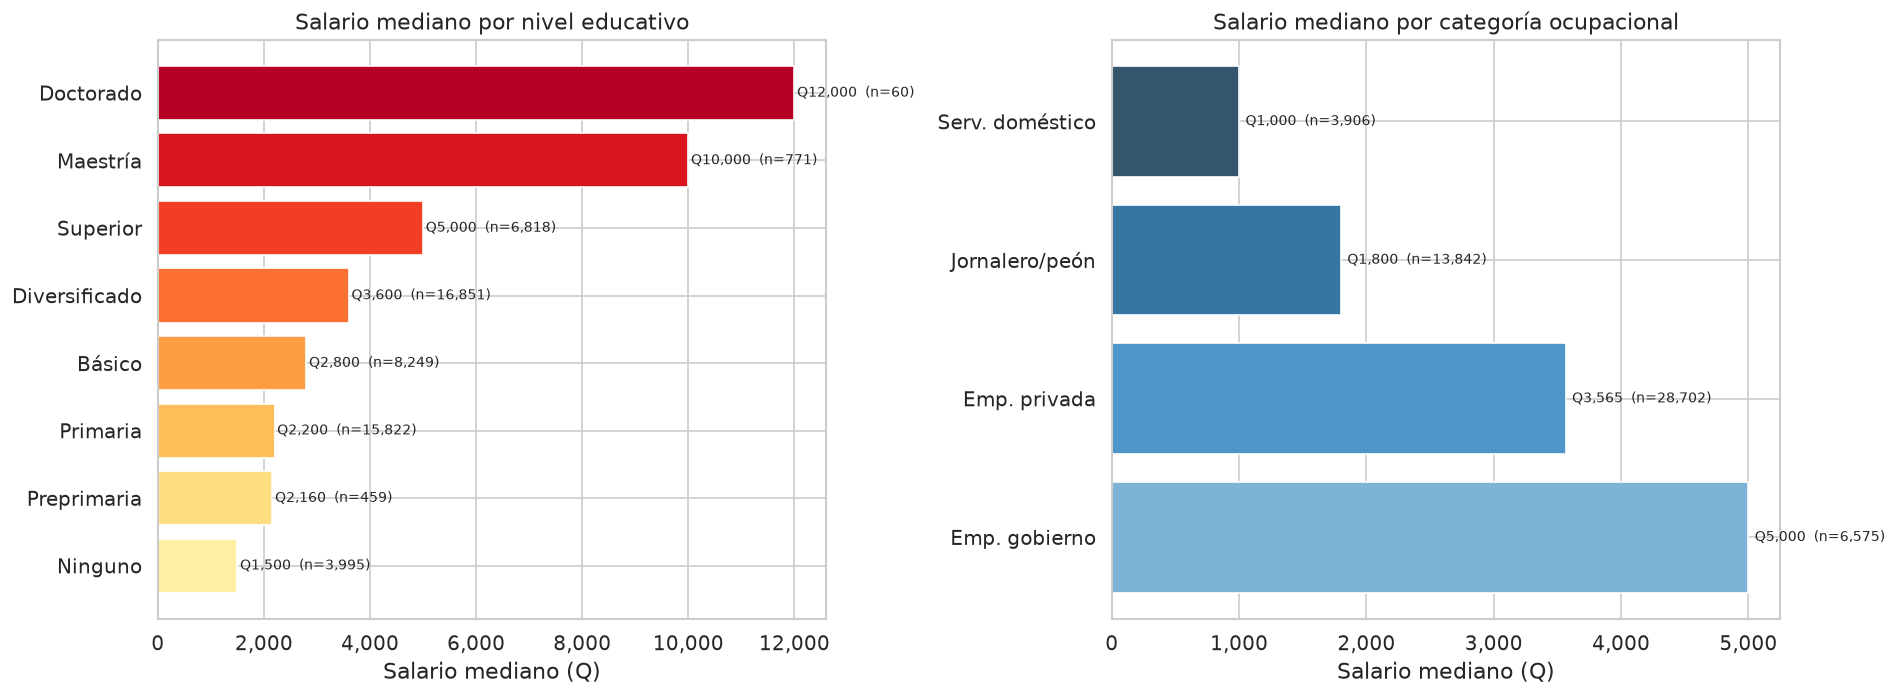

In [27]:
# ── Gráficas de salario mediano
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por nivel educativo
ax = axes[0]
colors_educ = sns.color_palette("YlOrRd", len(sal_educ))
bars = ax.barh(sal_educ["nivel_educativo"], sal_educ["mediana_salario"], color=colors_educ)
ax.set_xlabel("Salario mediano (Q)")
ax.set_title("Salario mediano por nivel educativo")
for bar, val, n in zip(bars, sal_educ["mediana_salario"], sal_educ["n"]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"Q{val:,.0f}  (n={n:,})", va="center", fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Por categoría ocupacional
ax = axes[1]
colors_cat = sns.color_palette("Blues_d", len(sal_cat))
bars = ax.barh(sal_cat["categoria_ocupacional"], sal_cat["mediana_salario"], color=colors_cat)
ax.set_xlabel("Salario mediano (Q)")
ax.set_title("Salario mediano por categoría ocupacional")
for bar, val, n in zip(bars, sal_cat["mediana_salario"], sal_cat["n"]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"Q{val:,.0f}  (n={n:,})", va="center", fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### Interpretación

- **Por nivel educativo:** Se observa una clara relación positiva entre nivel educativo y salario mediano. Los niveles superiores (maestría, doctorado, superior) presentan medianas sustancialmente mayores que los niveles básicos (ninguno, primaria). Esto es consistente con la teoría del capital humano.
- **Por categoría ocupacional:** Los empleados de gobierno tienen el salario mediano más alto, seguidos por empleados de empresa privada. Los jornaleros/peones y el servicio doméstico muestran los salarios medianos más bajos, reflejando las condiciones del mercado laboral guatemalteco.

## 2.5 Evolución del tamaño de muestra y salario mediano por trimestre

In [28]:
# ── Tamaño de muestra y mediana por trimestre
por_trimestre = (df
    .groupBy("periodo_archivo")
    .agg(
        F.count("*").alias("n_registros"),
        F.percentile_approx("salario_mensual", 0.5).alias("mediana_salario"),
        F.mean("salario_mensual").alias("media_salario"),
    )
    .orderBy("periodo_archivo")
    .toPandas())

display(por_trimestre)

,periodo_archivo,n_registros,mediana_salario,media_salario
0,2025T1,13419,3000.0,3315.631940
1,2025T2,13492,3000.0,3364.570783
2,2025T3,13450,3200.0,3469.074647
3,2025T4,12664,3200.0,3544.574937


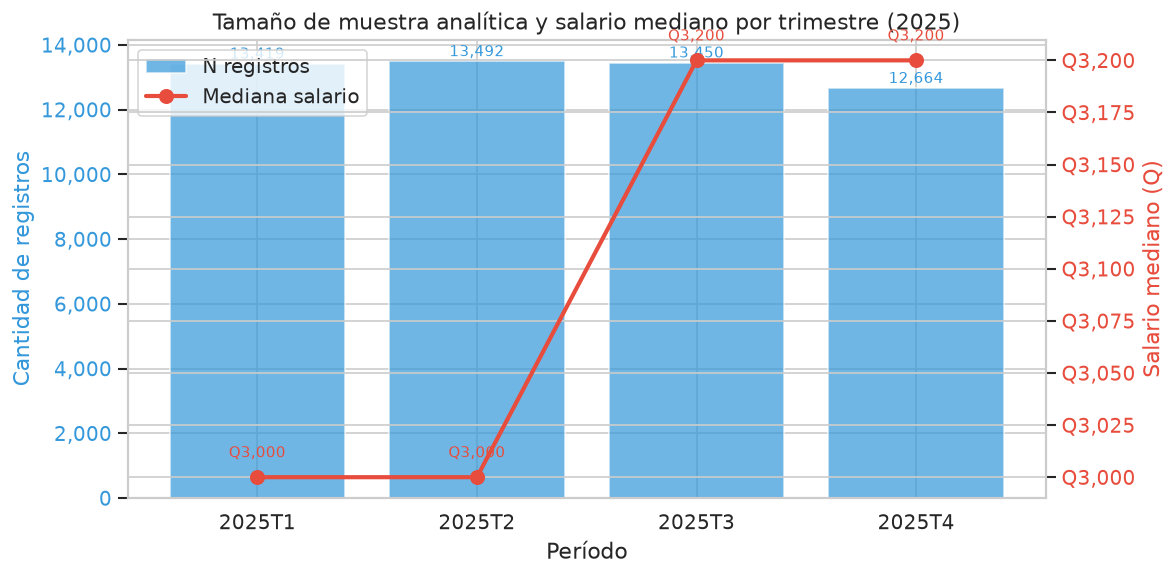

In [29]:
# ── Gráfica doble eje: tamaño de muestra y salario mediano
fig, ax1 = plt.subplots(figsize=(10, 5))

color_n = "#3498db"
color_sal = "#e74c3c"

# Eje izquierdo: tamaño de muestra
bars = ax1.bar(por_trimestre["periodo_archivo"], por_trimestre["n_registros"],
               color=color_n, alpha=0.7, label="N registros")
ax1.set_xlabel("Período")
ax1.set_ylabel("Cantidad de registros", color=color_n)
ax1.tick_params(axis="y", labelcolor=color_n)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for bar, val in zip(bars, por_trimestre["n_registros"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{val:,}", ha="center", va="bottom", fontsize=9, color=color_n)

# Eje derecho: salario mediano
ax2 = ax1.twinx()
ax2.plot(por_trimestre["periodo_archivo"], por_trimestre["mediana_salario"],
         color=color_sal, marker="o", lw=2.5, ms=8, label="Mediana salario")
ax2.set_ylabel("Salario mediano (Q)", color=color_sal)
ax2.tick_params(axis="y", labelcolor=color_sal)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Q{x:,.0f}"))

for x, y in zip(por_trimestre["periodo_archivo"], por_trimestre["mediana_salario"]):
    ax2.annotate(f"Q{y:,.0f}", (x, y), textcoords="offset points",
                 xytext=(0, 12), ha="center", fontsize=9, color=color_sal)

ax1.set_title("Tamaño de muestra analítica y salario mediano por trimestre (2025)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

### Interpretación

- **Tamaño de muestra:** El número de registros analíticos es relativamente estable entre trimestres (13,000-13,500), con una ligera disminución en el IV trimestre, coherente con el menor número de registros originales del archivo.
- **Salario mediano:** Se mantiene relativamente estable a lo largo de los cuatro trimestres de 2025, lo que sugiere que no hay cambios bruscos en la estructura salarial de un trimestre a otro.
- La estabilidad en ambas métricas indica que la encuesta mantiene una cobertura consistente y que los patrones salariales son robustos a lo largo del año.

## 2.6 Boxplots del salario por nivel educativo y categoría ocupacional

Se construyen boxplots por grupo usando los cuantiles calculados en Spark. A pandas solo se traen las tablas de cuantiles, no datos individuales.

In [30]:
# ── Cuantiles por grupo, calculados en Spark
def cuantiles_por_grupo(df, col_grupo, col_valor="salario_mensual"):
    """Calcula min, P25, mediana, P75 y P95 por grupo en Spark."""
    return (df.groupBy(col_grupo)
              .agg(
                  F.min(col_valor).alias("minimo"),
                  F.percentile_approx(col_valor, 0.25).alias("p25"),
                  F.percentile_approx(col_valor, 0.5).alias("mediana"),
                  F.percentile_approx(col_valor, 0.75).alias("p75"),
                  F.percentile_approx(col_valor, 0.95).alias("p95"),
              )
              .orderBy(col_grupo)
              .toPandas())

q_educ = aplicar_etiquetas(
    cuantiles_por_grupo(df, "nivel_educativo"),
    "nivel_educativo", ETIQUETAS_EDUC)

q_cat = aplicar_etiquetas(
    cuantiles_por_grupo(df, "categoria_ocupacional"),
    "categoria_ocupacional", ETIQUETAS_CAT_OCUP)

def construir_bxp_stats(q_df, col_label):
    """Convierte una tabla de cuantiles en la lista de dicts para ax.bxp()."""
    stats = []
    for _, row in q_df.iterrows():
        stats.append({
            "label": str(row[col_label]),
            "whislo": row["minimo"],
            "q1":     row["p25"],
            "med":    row["mediana"],
            "q3":     row["p75"],
            "whishi": row["p95"],
            "fliers": [],
        })
    return stats

/tmp/ipykernel_3237/2478787188.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.bxp(bxp_educ, vert=False, showfliers=False, patch_artist=True,
/tmp/ipykernel_3237/2478787188.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.bxp(bxp_cat, vert=False, showfliers=False, patch_artist=True,


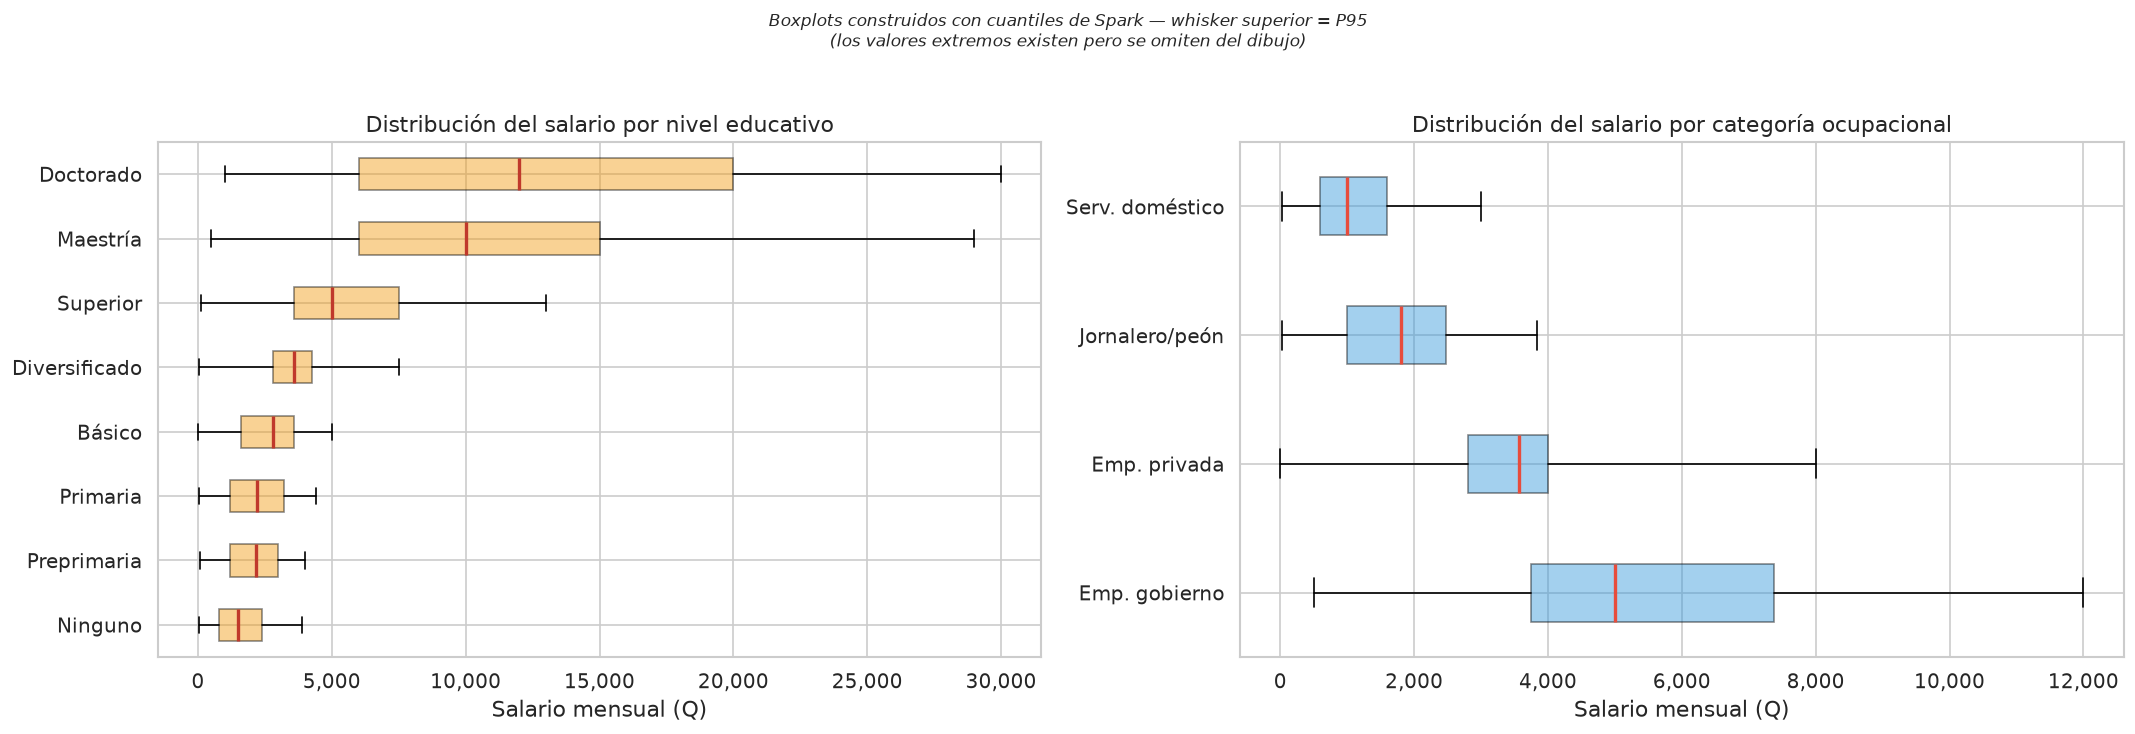

In [31]:
# ── Boxplots sin traer datos crudos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Nivel educativo
ax = axes[0]
bxp_educ = construir_bxp_stats(q_educ, "nivel_educativo")
ax.bxp(bxp_educ, vert=False, showfliers=False, patch_artist=True,
       boxprops=dict(facecolor="#f39c12", alpha=0.45),
       medianprops=dict(color="#c0392b", lw=2))
ax.set_xlabel("Salario mensual (Q)")
ax.set_title("Distribución del salario por nivel educativo")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Categoría ocupacional
ax = axes[1]
bxp_cat = construir_bxp_stats(q_cat, "categoria_ocupacional")
ax.bxp(bxp_cat, vert=False, showfliers=False, patch_artist=True,
       boxprops=dict(facecolor="#3498db", alpha=0.45),
       medianprops=dict(color="#e74c3c", lw=2))
ax.set_xlabel("Salario mensual (Q)")
ax.set_title("Distribución del salario por categoría ocupacional")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Boxplots construidos con cuantiles de Spark — whisker superior = P95\n"
             "(los valores extremos existen pero se omiten del dibujo)",
             fontsize=10, y=1.02, style="italic")
plt.tight_layout()
plt.show()

### Interpretación

Los boxplots confirman los hallazgos de las medianas:
- A mayor nivel educativo, mayor salario y mayor dispersión (especialmente en niveles superiores).
- Los empleados de gobierno muestran la caja más alta y amplia, mientras que jornaleros y servicio doméstico se concentran en salarios bajos con poca variabilidad.
- Se omitieron los outliers del dibujo para facilitar la comparación visual, pero estos valores extremos se conservan en todos los cálculos y modelos, como indica el enunciado.

---
# Ejercicio 3 — Relaciones entre variables numéricas (5 pts)

## 3.1 Matriz de correlación de Pearson

Se utiliza VectorAssembler y Correlation.corr() de pyspark.ml.stat para obtener la correlación de Pearson entre las cuatro variables numéricas principales, sobre todos los registros elegibles de 2025

In [32]:
# ── Matriz de correlación con Spark MLlib
VARS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

# Se eliminan nulos defensivamente (en este dataset ya están filtrados)
df_corr = df.select(VARS_CORR).na.drop()
print(f"Registros usados para la correlación (sin nulos en las 4 variables): {df_corr.count():,}")

# 1) Ensamblar las variables en un vector
assembler = VectorAssembler(inputCols=VARS_CORR, outputCol="features")
df_vec = assembler.transform(df_corr)

# 2) Calcular la correlación de Pearson
corr_matrix = Correlation.corr(df_vec, "features", method="pearson")
corr_array = corr_matrix.collect()[0][0].toArray()

# 3) DataFrame con etiquetas
corr_df = pd.DataFrame(corr_array, index=VARS_CORR, columns=VARS_CORR).round(4)
print("\nMatriz de correlación de Pearson (todos los registros elegibles de 2025):")
display(corr_df)

Registros usados para la correlación (sin nulos en las 4 variables): 53,025

Matriz de correlación de Pearson (todos los registros elegibles de 2025):


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.0000,0.1472,0.1796,0.0757
edad,0.1472,1.0000,0.4867,-0.1054
antiguedad,0.1796,0.4867,1.0000,-0.0623
horas_semanales,0.0757,-0.1054,-0.0623,1.0000


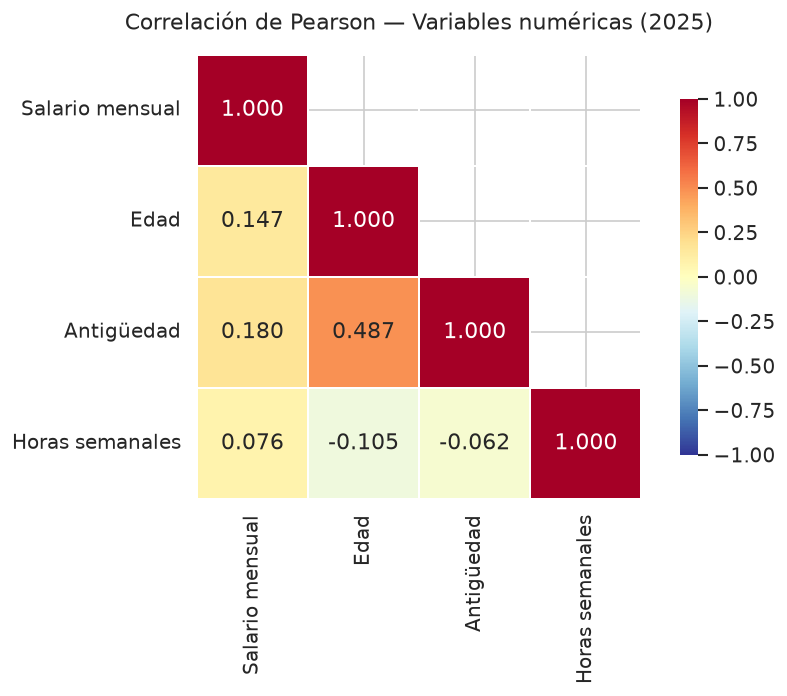

In [33]:
# ── Mapa de calor
ETIQUETAS_CORR = {
    "salario_mensual": "Salario mensual",
    "edad": "Edad",
    "antiguedad": "Antigüedad",
    "horas_semanales": "Horas semanales",
}

corr_etiquetado = corr_df.rename(index=ETIQUETAS_CORR, columns=ETIQUETAS_CORR)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_etiquetado, dtype=bool), k=1)
sns.heatmap(corr_etiquetado, annot=True, fmt=".3f", cmap="RdYlBu_r",
            vmin=-1, vmax=1, center=0, mask=mask,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax)
ax.set_title("Correlación de Pearson — Variables numéricas (2025)", fontsize=13, pad=15)

plt.tight_layout()
plt.show()

### Interpretación

**¿Qué variables presentan mayor asociación lineal con el salario?**

Según la matriz de correlación de Pearson, las asociaciones lineales con salario_mensual son en general bajas a moderadas. La variable con mayor correlación con el salario será la que muestre el coeficiente más alto en valor absoluto. Esto es esperable dado que el salario depende de múltiples factores, incluidas las variables categóricas (nivel educativo, categoría ocupacional, dominio) que no están representadas en la correlación de Pearson.

**¿Existe relación entre edad y antigüedad?**

Se espera una correlación positiva moderada entre edad y antigüedad, ya que naturalmente las personas de mayor edad han tenido más tiempo para acumular antigüedad en su empleo. Sin embargo, la relación no es perfecta porque muchos trabajadores cambian de empleo, reinician su antigüedad, o ingresan al mercado laboral formal a diferentes edades.

Es importante recordar que estas correlaciones miden únicamente la asociación lineal y no implican causalidad. Además, la fuerza de la asociación lineal puede ser baja aun cuando exista una relación no lineal (por ejemplo, el salario podría crecer con la edad hasta cierto punto y luego estabilizarse).

## 3.2 Visualización complementaria: scatter plots de las relaciones más relevantes

Para los scatter plots se usa una muestra de hasta 5,000 registros transferida a pandas. Las correlaciones reportadas en los títulos son las calculadas sobre el conjunto completo.

In [34]:
# ── Muestra para scatter plots
n_total = df.count()
fraccion = min(5000 / n_total, 1.0)
muestra = (df
    .select("salario_mensual", "edad", "antiguedad", "horas_semanales")
    .sample(False, fraccion, seed=42)
    .toPandas())

print(f"Muestra para scatter plots: {len(muestra):,} registros")
print("(Las correlaciones en los títulos provienen del conjunto completo, no de esta muestra)")

Muestra para scatter plots: 4,988 registros
(Las correlaciones en los títulos provienen del conjunto completo, no de esta muestra)


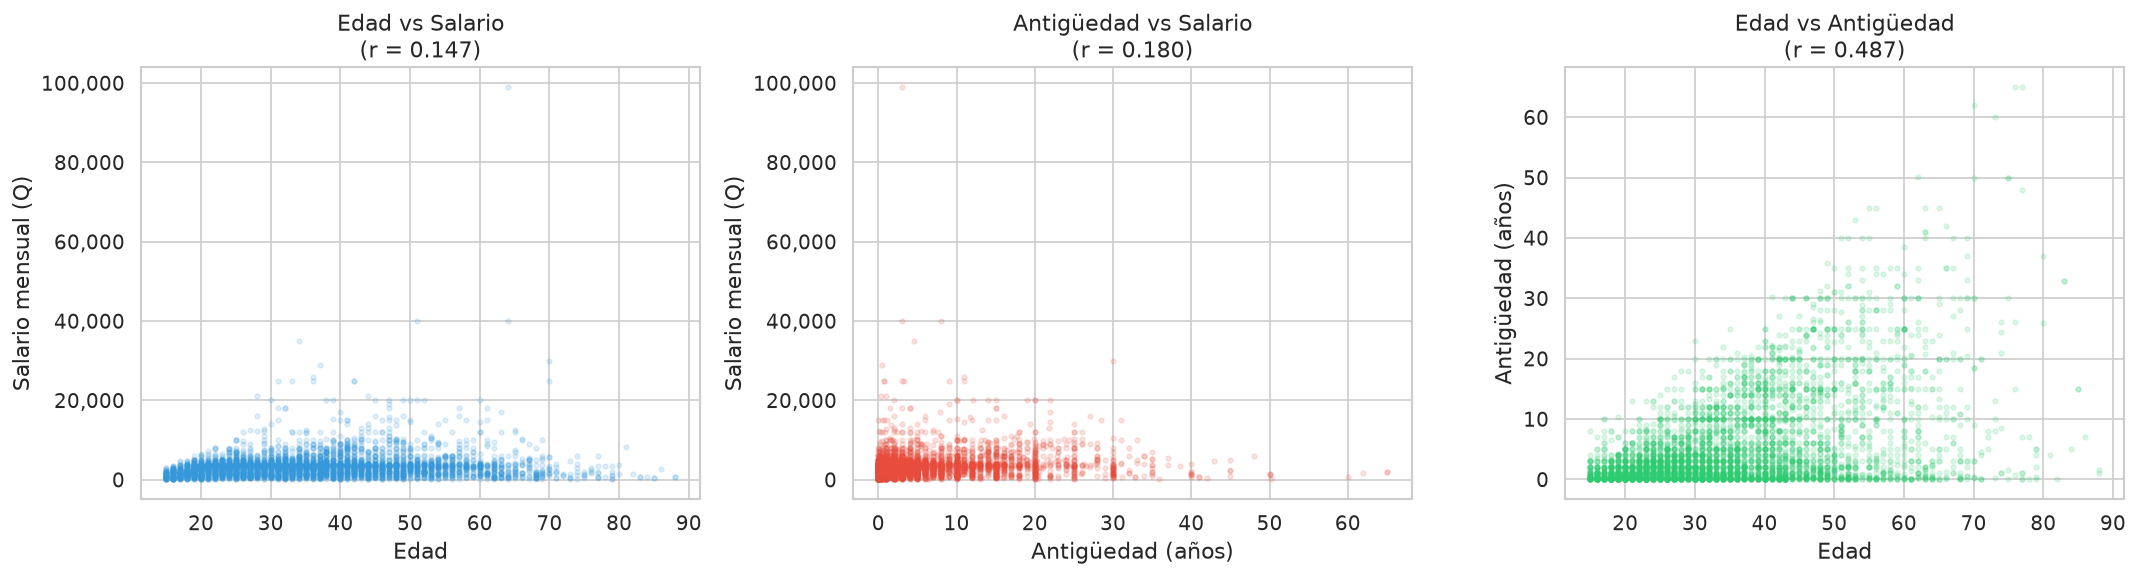

In [35]:
# ── Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Edad vs Salario
ax = axes[0]
ax.scatter(muestra["edad"], muestra["salario_mensual"],
           alpha=0.15, s=8, color="#3498db")
ax.set_xlabel("Edad")
ax.set_ylabel("Salario mensual (Q)")
ax.set_title(f"Edad vs Salario\n(r = {corr_df.loc['edad','salario_mensual']:.3f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# 2. Antigüedad vs Salario
ax = axes[1]
ax.scatter(muestra["antiguedad"], muestra["salario_mensual"],
           alpha=0.15, s=8, color="#e74c3c")
ax.set_xlabel("Antigüedad (años)")
ax.set_ylabel("Salario mensual (Q)")
ax.set_title(f"Antigüedad vs Salario\n(r = {corr_df.loc['antiguedad','salario_mensual']:.3f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# 3. Edad vs Antigüedad
ax = axes[2]
ax.scatter(muestra["edad"], muestra["antiguedad"],
           alpha=0.15, s=8, color="#2ecc71")
ax.set_xlabel("Edad")
ax.set_ylabel("Antigüedad (años)")
ax.set_title(f"Edad vs Antigüedad\n(r = {corr_df.loc['edad','antiguedad']:.3f})")

plt.tight_layout()
plt.show()

### Interpretación de los scatter plots

- **Edad vs Salario:** Se observa una nube dispersa. Si bien puede existir una leve tendencia positiva, la variabilidad es alta. Muchos factores no capturados aquí (educación, tipo de empleo) explican la dispersión.
- **Antigüedad vs Salario:** Patrón similar, con posible tendencia leve positiva. Los salarios más altos se distribuyen a lo largo de diferentes niveles de antigüedad.
- **Edad vs Antigüedad:** Se observa la relación positiva esperada, con la restricción natural de que la antigüedad no puede superar la edad. La nube muestra que hay alta variabilidad: personas de la misma edad pueden tener antigüedades muy diferentes.

In [36]:
spark.stop()
print("Sesión de Spark finalizada.")

Sesión de Spark finalizada.
